In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\OFFICE\GOLDSTONE\cementAI\Data\cement_dataset_cleaned_category_fineness_fullyear.csv")


df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
cols = [
    "Timestamp",
    "TOTALTPH",
    "REJECTTPH",
    "CMOLBEAMP",
    "MILLSOUNDPercent",
    "cement_category"
]
data = df[cols].copy()
data.describe()

,Timestamp,TOTALTPH,REJECTTPH,CMOLBEAMP,MILLSOUNDPercent,cement_category
count,7574,7574.000000,7574.000000,7574.000000,7574.000000,7574.000000
mean,2025-07-15 05:33:23.908107008,115.854831,114.752995,53.413121,79.867026,0.271191
min,2025-01-01 00:00:00,60.864471,0.000000,40.586082,41.172161,0.000000
25%,2025-03-29 01:15:00,109.915693,31.903542,47.912086,74.896217,0.000000
50%,2025-07-09 01:30:00,116.562025,90.792435,50.940174,79.682541,0.000000
75%,2025-11-09 11:45:00,123.019908,198.474976,57.582420,84.786324,1.000000
max,2026-01-30 23:00:00,151.288400,264.546997,83.076927,96.923080,1.000000
std,NaN,11.913128,93.613402,7.336166,7.231554,0.444604


# Relation 3: Reject TPH as diagnostic layer
❗ Relation 3 is NOT a standalone control loop
✅ It is a validation + modifier layer

In [2]:
cols = [
    "Timestamp",
    "TOTALTPH",
    "REJECTTPH",
    "cement_category"
]

data_r3 = df[cols].copy()
data_r3

,Timestamp,TOTALTPH,REJECTTPH,cement_category
0,2025-01-01 00:00:00,121.751163,151.752136,0.0
1,2025-01-01 01:00:00,119.021003,0.194139,0.0
2,2025-01-01 02:00:00,122.926258,104.770454,0.0
3,2025-01-01 03:00:00,121.687425,123.925522,0.0
4,2025-01-01 04:00:00,122.418812,194.721619,0.0
...,...,...,...,...
7569,2026-01-30 19:00:00,110.864470,264.094025,1.0
7570,2026-01-30 20:00:00,99.130651,243.126984,0.0
7571,2026-01-30 21:00:00,104.230777,79.661789,0.0
7572,2026-01-30 22:00:00,104.261301,215.429794,0.0


# Split Categories

In [3]:
cat0_r3 = data_r3[data_r3["cement_category"] == 0].copy()
cat1_r3 = data_r3[data_r3["cement_category"] == 1].copy()
cat0_r3.shape

(5520, 4)

# Basic Cleaning 

In [4]:
cat0_r3b = cat0_r3.copy()

cat0_r3b = cat0_r3b[
    (cat0_r3b["TOTALTPH"] > 80) &
    (cat0_r3b["REJECTTPH"] > 10)
].copy()

print("After basic filtering:", cat0_r3b.shape)

After basic filtering: (4530, 4)


# Remove Outliers

In [5]:
tph_upper = cat0_r3b["TOTALTPH"].quantile(0.99)
reject_upper = cat0_r3b["REJECTTPH"].quantile(0.99)

cat0_r3b = cat0_r3b[
    (cat0_r3b["TOTALTPH"] <= tph_upper) &
    (cat0_r3b["REJECTTPH"] <= reject_upper)
].copy()

print("After outlier removal:", cat0_r3b.shape)

After outlier removal: (4469, 4)


# Create Feed Bins

In [6]:
bin_width = 2

cat0_r3b["feed_bin_start"] = (cat0_r3b["TOTALTPH"] // bin_width) * bin_width
cat0_r3b["feed_bin_end"] = cat0_r3b["feed_bin_start"] + bin_width

cat0_r3b["feed_bin"] = (
    cat0_r3b["feed_bin_start"].astype(int).astype(str) + "-" +
    cat0_r3b["feed_bin_end"].astype(int).astype(str))

# Build Reject Envelope

In [8]:
reject_env = (
    cat0_r3b.groupby("feed_bin_start")["REJECTTPH"]
    .agg(
        reject_q25=lambda x: x.quantile(0.25),
        reject_median="median",
        reject_q75=lambda x: x.quantile(0.75),
        count="count"
    )
    .reset_index()
)

reject_env["feed_bin_end"] = reject_env["feed_bin_start"] + bin_width

reject_env["feed_bin"] = (
    reject_env["feed_bin_start"].astype(int).astype(str) + "-" +
    reject_env["feed_bin_end"].astype(int).astype(str)
)

reject_env.shape

(31, 7)

# Remove Weak Bins

In [9]:
reject_env = reject_env[reject_env["count"] >= 5].copy()

print("Valid bins:", reject_env.shape)

Valid bins: (31, 7)


# Merge Back

In [10]:
cat0_r3b = cat0_r3b.merge(
    reject_env[["feed_bin_start", "reject_q25", "reject_median", "reject_q75"]],
    on="feed_bin_start",
    how="left"
)

# Classification 

In [11]:
def classify_reject(row):
    if pd.isna(row["reject_q25"]) or pd.isna(row["reject_q75"]):
        return np.nan
    elif row["REJECTTPH"] < row["reject_q25"]:
        return "Low Reject"
    elif row["REJECTTPH"] > row["reject_q75"]:
        return "High Reject"
    else:
        return "Normal Reject"

cat0_r3b["reject_status"] = cat0_r3b.apply(classify_reject, axis=1)

cat0_r3b["reject_status"].value_counts()

reject_status
Normal Reject    2248
Low Reject       1117
High Reject      1104
Name: count, dtype: int64

# Deviation & Severity

In [12]:
cat0_r3b["reject_deviation"] = cat0_r3b["REJECTTPH"] - cat0_r3b["reject_median"]

cat0_r3b["reject_bandwidth"] = cat0_r3b["reject_q75"] - cat0_r3b["reject_q25"]

cat0_r3b["reject_bandwidth"] = cat0_r3b["reject_bandwidth"].replace(0, np.nan)

cat0_r3b["reject_severity"] = cat0_r3b["reject_deviation"] / cat0_r3b["reject_bandwidth"]

# Final columns

In [13]:
final_cols_r3 = [
    "Timestamp",
    "TOTALTPH",
    "REJECTTPH",
    "feed_bin",
    "reject_q25",
    "reject_median",
    "reject_q75",
    "reject_status",
    "reject_deviation",
    "reject_severity"
]

cat0_r3b[final_cols_r3]

,Timestamp,TOTALTPH,REJECTTPH,feed_bin,reject_q25,reject_median,reject_q75,reject_status,reject_deviation,reject_severity
0,2025-01-01 00:00:00,121.751163,151.752136,120-122,53.857449,100.758244,167.687733,Normal Reject,50.993893,0.447982
1,2025-01-01 02:00:00,122.926258,104.770454,122-124,50.735043,88.656898,158.741150,Normal Reject,16.113556,0.149191
2,2025-01-01 03:00:00,121.687425,123.925522,120-122,53.857449,100.758244,167.687733,Normal Reject,23.167278,0.203525
3,2025-01-01 04:00:00,122.418812,194.721619,122-124,50.735043,88.656898,158.741150,High Reject,106.064720,0.982025
4,2025-01-01 07:00:00,126.301349,80.761909,126-128,64.680708,117.777779,204.007942,Normal Reject,-37.015869,-0.265676
...,...,...,...,...,...,...,...,...,...,...
4464,2026-01-30 15:00:00,107.122108,250.115997,106-108,51.592493,88.203907,228.825397,High Reject,161.912090,0.913555
4465,2026-01-30 20:00:00,99.130651,243.126984,98-100,64.454218,104.673386,187.166359,High Reject,138.453598,1.128280
4466,2026-01-30 21:00:00,104.230777,79.661789,104-106,55.297314,124.702076,264.094025,Normal Reject,-45.040287,-0.215714
4467,2026-01-30 22:00:00,104.261301,215.429794,104-106,55.297314,124.702076,264.094025,Normal Reject,90.727718,0.434527


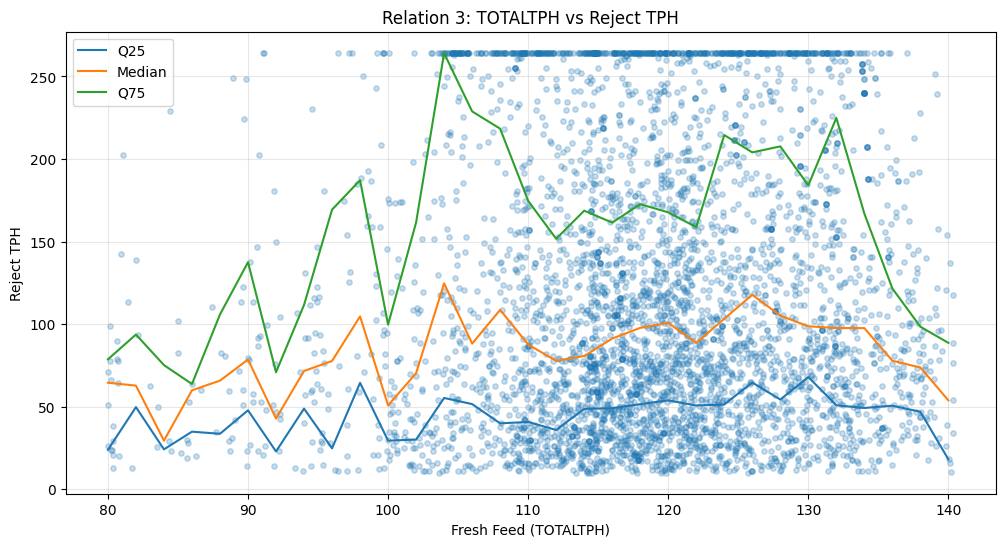

In [14]:
plt.figure(figsize=(12,6))

plt.scatter(cat0_r3b["TOTALTPH"], cat0_r3b["REJECTTPH"], alpha=0.25, s=15)

plt.plot(reject_env["feed_bin_start"], reject_env["reject_q25"], label="Q25")
plt.plot(reject_env["feed_bin_start"], reject_env["reject_median"], label="Median")
plt.plot(reject_env["feed_bin_start"], reject_env["reject_q75"], label="Q75")

plt.xlabel("Fresh Feed (TOTALTPH)")
plt.ylabel("Reject TPH")
plt.title("Relation 3: TOTALTPH vs Reject TPH")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()